# Tugas Klasifikasi dengan Decision Tree dan Random Forest Menggunakan data bertema film (buatan sendiri)

Anggota kelompok
- Galang Adika Ramadhan (24523275)
- Muhammad Fadli (24523227)
- Muhammad Fikri Saleh (24523153)

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [27]:
data = {
    'Budget': [100, 50, 200, 30, 150, 80, 60, 120, 40, 90,
               110, 70, 160, 55, 140, 85, 65, 130, 45, 95,
               105, 75, 170, 60, 155, 88, 68, 125, 48, 92],

    'Duration': [120, 90, 150, 85, 130, 110, 95, 140, 100, 105,
                 125, 92, 145, 88, 135, 115, 98, 142, 102, 108,
                 122, 94, 148, 90, 138, 112, 97, 139, 101, 106],

    'Genre': ['Action', 'Comedy', 'Action', 'Drama', 'Action', 'Comedy', 'Drama', 'Action', 'Comedy', 'Drama',
              'Action', 'Comedy', 'Action', 'Drama', 'Action', 'Comedy', 'Drama', 'Action', 'Comedy', 'Drama',
              'Action', 'Comedy', 'Action', 'Drama', 'Action', 'Comedy', 'Drama', 'Action', 'Comedy', 'Drama'],

    'Rating': [8.5, 6.0, 9.0, 5.5, 8.0, 6.5, 5.0, 8.8, 6.2, 5.8,
               8.6, 6.3, 9.1, 5.7, 8.2, 6.6, 5.2, 8.9, 6.1, 5.9,
               8.4, 6.4, 9.2, 5.6, 8.3, 6.7, 5.3, 8.7, 6.0, 5.7],

    'Success': [1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
                1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
                1, 0, 1, 0, 1, 0, 0, 1, 0, 0]
}

df = pd.DataFrame(data)
df

,Budget,Duration,Genre,Rating,Success
0,100,120,Action,8.5,1
1,50,90,Comedy,6.0,0
2,200,150,Action,9.0,1
3,30,85,Drama,5.5,0
4,150,130,Action,8.0,1
5,80,110,Comedy,6.5,0
6,60,95,Drama,5.0,0
7,120,140,Action,8.8,1
8,40,100,Comedy,6.2,0
9,90,105,Drama,5.8,0


Dataset ini berisi informasi mengenai film seperti budget, durasi, genre, dan rating. Tujuan dari klasifikasi adalah memprediksi apakah sebuah film tergolong sukses atau tidak.

In [28]:
#PREPROCESSING
df = pd.get_dummies(df, columns=['Genre'])

Fitur kategorikal yaitu genre diubah menjadi bentuk numerik menggunakan teknik one-hot encoding agar dapat diproses oleh model machine learning.

In [29]:
#SPLIT DATA
from sklearn.model_selection import train_test_split

X = df.drop('Success', axis=1)
y = df['Success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Dataset dibagi menjadi data latih dan data uji. Data latih digunakan untuk melatih model, sedangkan data uji digunakan untuk mengevaluasi performa model.

In [30]:
#DECISION TREE
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

Model Decision Tree dibangun untuk melakukan klasifikasi berdasarkan aturan-aturan yang terbentuk dari data training.

In [31]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

Model Random Forest dibangun dengan menggabungkan banyak Decision Tree untuk menghasilkan prediksi yang lebih stabil dan akurat.

In [36]:
#PREDIKSI
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

hasil = pd.DataFrame({
    'Actual': y_test.values,
    'DT_Pred': y_pred_dt,
    'RF_Pred': y_pred_rf
})

hasil.head()

,Actual,DT_Pred,RF_Pred
0,1,1,1
1,0,0,0
2,0,0,0
3,1,1,1
4,0,0,0


Tabel ini menampilkan perbandingan antara nilai sebenarnya (Actual) dengan hasil prediksi dari Decision Tree dan Random Forest. Dari tabel ini dapat dilihat apakah model sudah memprediksi dengan benar atau masih terdapat kesalahan. Menurut saya, meskipun hasilnya sangat baik, dataset yang digunakan masih terlalu sederhana sehingga belum sepenuhnya mencerminkan kondisi nyata.

In [33]:
#EVALUASI
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nDecision Tree Report:\n", classification_report(y_test, y_pred_dt))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0

Decision Tree Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9


Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



Evaluasi dilakukan menggunakan accuracy, classification report, dan confusion matrix untuk mengetahui performa model dalam melakukan klasifikasi.

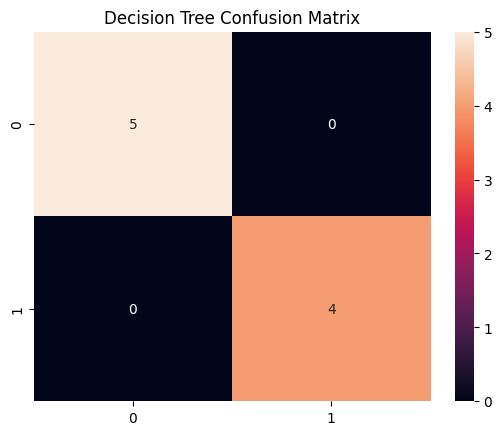

In [34]:
#CONFUSION MATRIX
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

Dari confusion matrix terlihat bahwa semua prediksi model sudah sesuai dengan data sebenarnya. Tidak ditemukan kesalahan prediksi, sehingga performa model dapat dikatakan sangat baik.

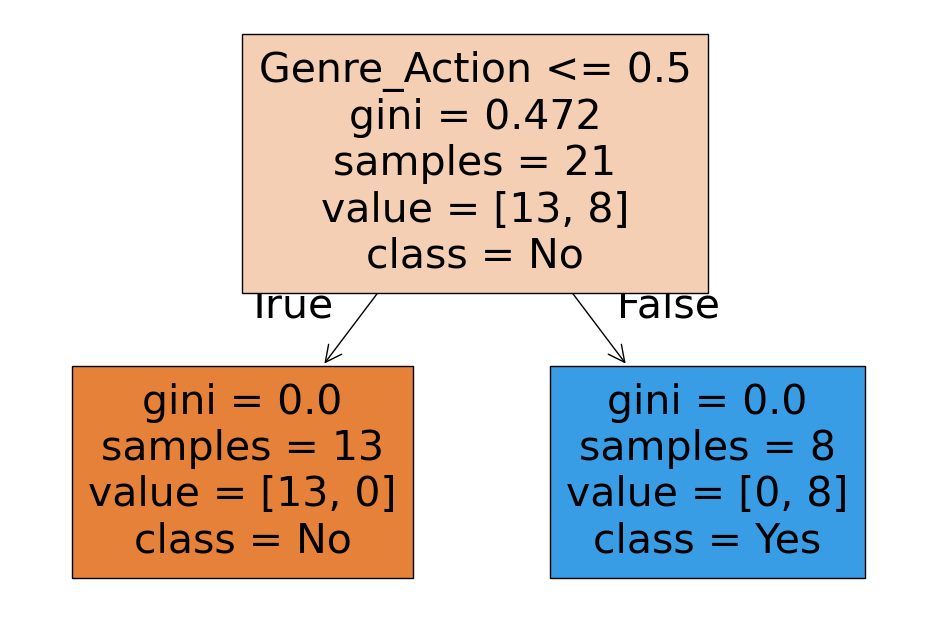

In [35]:
#VISUALISASI TREE
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(dt_model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

Dari visualisasi pohon terlihat bahwa model hanya membutuhkan satu aturan utama, yaitu rating, untuk menentukan apakah film sukses atau tidak. Ini menunjukkan bahwa fitur rating sangat berpengaruh dalam dataset ini.

In [37]:
#Uji n_estimators
for n in [10, 50, 100]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    print(f"n_estimators={n}, accuracy={accuracy_score(y_test, pred)}")

n_estimators=10, accuracy=1.0
n_estimators=50, accuracy=1.0
n_estimators=100, accuracy=1.0


Parameter n_estimators menentukan jumlah pohon dalam Random Forest. Semakin banyak pohon, biasanya hasil prediksi menjadi lebih stabil, namun membutuhkan waktu komputasi lebih lama.

# Perbandingan hasil model
Dari hasil yang diperoleh, kedua model memberikan hasil yang sama baiknya. Namun, Decision Tree lebih sederhana dan mudah dipahami, sedangkan Random Forest lebih kuat karena menggabungkan banyak pohon sehingga hasilnya lebih stabil dan tidak mudah overfitting.

# Analisis
1. Algoritma mana yang memberikan performa terbaik?

Dari hasil yang didapat, Decision Tree dan Random Forest sama-sama punya performa yang sangat baik, bahkan akurasinya sampai 1.0. Artinya kedua model bisa memprediksi data dengan benar semua pada dataset ini.

Tapi kalau dilihat secara umum, Random Forest biasanya lebih unggul karena dia menggunakan banyak pohon keputusan, jadi hasilnya lebih stabil. Menurut saya, walaupun di sini hasilnya sama, Random Forest tetap lebih bisa diandalkan kalau datanya lebih kompleks.

2. Kelebihan dan kekurangan Decision Tree dibanding Random Forest

Decision Tree

Kelebihan:

- Mudah dipahami dan dilihat alurnya
- Prosesnya cepat
- Cocok untuk data yang sederhana

Kekurangan:

- Mudah overfitting (terlalu ngikut data training)
- Kurang stabil kalau ada perubahan data

Random Forest

Kelebihan:

- Lebih akurat dan stabil
- Tidak gampang overfitting
- Cocok untuk data yang lebih kompleks

Kekurangan:

- Lebih sulit dipahami
- Prosesnya lebih lama dibanding - Decision Tree

3. Apakah ada indikasi overfitting pada Decision Tree?

Menurut saya, ada kemungkinan terjadi overfitting. Soalnya model bisa mendapatkan akurasi yang sangat tinggi, bahkan sempurna. Ini biasanya terjadi kalau model terlalu “menghafal” data training.

Selain itu, dari bentuk pohonnya yang sederhana tapi bisa memisahkan data dengan sempurna, terlihat bahwa dataset yang digunakan memang cukup mudah, jadi model tidak terlalu diuji dengan kondisi yang lebih kompleks.

4. Bagaimana fitur-fitur memengaruhi hasil klasifikasi?

Dari hasil visualisasi Decision Tree, terlihat bahwa fitur rating punya pengaruh paling besar dalam menentukan apakah film itu sukses atau tidak. Model langsung menggunakan rating sebagai aturan utama.

Sementara itu, fitur lain seperti budget dan durasi tetap berpengaruh, tapi tidak sebesar rating. Jadi bisa dibilang, semakin tinggi rating film, semakin besar kemungkinan film tersebut dianggap sukses.


1. Apa perbedaan mendasar antara Decision Tree dan Random Forest?

Perbedaan utamanya ada di jumlah model yang digunakan. Decision Tree cuma pakai satu pohon keputusan untuk klasifikasi, jadi hasilnya langsung dari satu model saja.

Sedangkan Random Forest menggunakan banyak pohon keputusan (ensemble), lalu hasilnya digabungkan. Jadi Random Forest biasanya lebih stabil dan tidak gampang salah dibanding Decision Tree.

2. Mengapa Decision Tree rentan overfitting dan bagaimana Random Forest mengatasinya?

Decision Tree rentan overfitting karena dia mencoba menyesuaikan data training sedetail mungkin, bahkan sampai ke pola yang sebenarnya tidak penting. Akibatnya, model jadi bagus di training tapi kurang bagus di data baru.

Random Forest mengatasi ini dengan membuat banyak pohon dari data yang berbeda-beda, lalu hasilnya digabungkan. Dengan cara ini, model tidak terlalu bergantung pada satu pola saja, jadi lebih general dan tidak mudah overfitting.

3. Apa fungsi bagging dan pemilihan subset fitur acak pada Random Forest?

Bagging digunakan untuk mengambil sampel data secara acak (dengan pengulangan) untuk membuat beberapa model. Tujuannya supaya tiap pohon belajar dari data yang sedikit berbeda.

Selain itu, Random Forest juga memilih subset fitur secara acak saat membangun pohon. Ini bertujuan agar setiap pohon tidak terlalu mirip, sehingga hasil akhirnya lebih beragam dan lebih stabil.

4. Kapan Decision Tree lebih cocok digunakan dibanding Random Forest?

Decision Tree lebih cocok digunakan ketika kita butuh model yang mudah dipahami dan dijelaskan, misalnya untuk presentasi atau analisis sederhana.

Selain itu, Decision Tree juga cocok untuk dataset kecil atau kasus yang tidak terlalu kompleks. Kalau datanya sudah besar dan kompleks, biasanya lebih baik pakai Random Forest.

# Jawaban Pertanyaan
1. Apa perbedaan mendasar antara Decision Tree dan Random Forest?

Perbedaan utamanya ada di jumlah model yang digunakan. Decision Tree cuma pakai satu pohon keputusan untuk klasifikasi, jadi hasilnya langsung dari satu model saja.

Sedangkan Random Forest menggunakan banyak pohon keputusan (ensemble), lalu hasilnya digabungkan. Jadi Random Forest biasanya lebih stabil dan tidak gampang salah dibanding Decision Tree.

2. Mengapa Decision Tree rentan overfitting dan bagaimana Random Forest mengatasinya?

Decision Tree rentan overfitting karena dia mencoba menyesuaikan data training sedetail mungkin, bahkan sampai ke pola yang sebenarnya tidak penting. Akibatnya, model jadi bagus di training tapi kurang bagus di data baru.

Random Forest mengatasi ini dengan membuat banyak pohon dari data yang berbeda-beda, lalu hasilnya digabungkan. Dengan cara ini, model tidak terlalu bergantung pada satu pola saja, jadi lebih general dan tidak mudah overfitting.

3. Apa fungsi bagging dan pemilihan subset fitur acak pada Random Forest?

Bagging digunakan untuk mengambil sampel data secara acak (dengan pengulangan) untuk membuat beberapa model. Tujuannya supaya tiap pohon belajar dari data yang sedikit berbeda.

Selain itu, Random Forest juga memilih subset fitur secara acak saat membangun pohon. Ini bertujuan agar setiap pohon tidak terlalu mirip, sehingga hasil akhirnya lebih beragam dan lebih stabil.

4. Kapan Decision Tree lebih cocok digunakan dibanding Random Forest?

Decision Tree lebih cocok digunakan ketika kita butuh model yang mudah dipahami dan dijelaskan, misalnya untuk presentasi atau analisis sederhana.

Selain itu, Decision Tree juga cocok untuk dataset kecil atau kasus yang tidak terlalu kompleks. Kalau datanya sudah besar dan kompleks, biasanya lebih baik pakai Random Forest.